### BEHAVIOURAL MODEL
goal: 
find (a) the loan id, (b) the time/age column, (c) delinquency,
(d) current UPB, (e) zero-balance/terminal code

In [ ]:
import pandas as pd, numpy as np
import pyarrow.parquet as pq

PERF_PATH = r"D:\Mortgage-Credit-Risk-Analytics\Data\processed\master_monthly_performance_clean.parquet"
schema = pq.read_schema(PERF_PATH)
print("COLUMNS IN MONTHLY FILE:")
for name, dtype in zip(schema.names, schema.types):
    print(f"  {name:40} {dtype}")

#small sample to see the shape of the data for ONE loan
sample = pd.read_parquet(PERF_PATH).head(50)
print("\nsample shape:", sample.shape)
one = sample[sample["loan_seq_no"] == sample["loan_seq_no"].iloc[0]]
print(f"\nall monthly rows for one loan ({one['loan_seq_no'].iloc[0]}):")
print(one.to_string())

COLUMNS IN MONTHLY FILE:
  loan_seq_no                              large_string
  monthly_reporting_period                 int64
  current_actual_upb                       double
  current_loan_delinquency_status          large_string
  loan_age                                 int64
  remaining_months_to_legal_maturity       double
  defect_settlement_date                   double
  modification_flag                        large_string
  zero_balance_code                        large_string
  zero_balance_effective_date              double
  current_interest_rate                    double
  current_non_interest_bearing_upb         double
  ddlpi                                    double
  mi_recoveries                            double
  net_sale_proceeds                        double
  non_mi_recoveries                        double
  total_expenses                           double
  legal_costs                              double
  maintenance_and_preservation_costs       double
  t

In [ ]:
# Building the ≤12-month observation slice

import pyarrow.parquet as pq
import pandas as pd, numpy as np

PERF_PATH = r"D:\Mortgage-Credit-Risk-Analytics\Data\raw\master_monthly_performance_clean.parquet"
NEED = ["loan_seq_no", "loan_age", "current_loan_delinquency_status",
        "current_actual_upb", "zero_balance_code", "eltv", "origination_year", "current_interest_rate"]

pf = pq.ParquetFile(PERF_PATH)
print("row groups:", pf.num_row_groups, "| total rows:", pf.metadata.num_rows)

obs_parts = []          # months 1–12 only (for features)
fwd_parts = []          # months 13+  only (for the forward label)
for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=NEED).to_pandas()

    # vintage filter 
    chunk = chunk[chunk["origination_year"].between(2000, 2010)]
    if chunk.empty:
        continue

    obs_parts.append(chunk[chunk["loan_age"] <= 12])
    fwd_parts.append(chunk[chunk["loan_age"] > 12][
        ["loan_seq_no", "loan_age", "current_loan_delinquency_status", "zero_balance_code"]])

    if rg % 10 == 0:
        print(f"  processed row group {rg}/{pf.num_row_groups}")

obs = pd.concat(obs_parts, ignore_index=True); del obs_parts
fwd = pd.concat(fwd_parts, ignore_index=True); del fwd_parts

print("\nobservation slice (months 1-12):", obs.shape)
print("forward slice (months 13+)     :", fwd.shape)
print("unique loans in obs:", obs['loan_seq_no'].nunique())
print("vintages present:", sorted(obs['origination_year'].unique()))

row groups: 32 | total rows: 33135526
  processed row group 0/32
  processed row group 10/32
  processed row group 20/32
  processed row group 30/32

observation slice (months 1-12): (6808339, 8)
forward slice (months 13+)     : (26327187, 4)
unique loans in obs: 545101
vintages present: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]


In [ ]:
# classifying first-12-months fate

def norm_zb(x):
    s = pd.Series(x).dropna().astype(str)
    out = set()
    for v in s:
        v = v.strip()
        try:
            out.add(str(int(float(v))))     # "01"->1->"1" ; "1.0"->1->"1"
        except ValueError:
            out.add(v)                       # keep "R","XX" etc as-is
    return out

dq = pd.to_numeric(obs["current_loan_delinquency_status"], errors="coerce")
obs = obs.assign(_dq=dq)

g = obs.groupby("loan_seq_no")
loan12 = pd.DataFrame({
    "max_dq_12": g["_dq"].max(),
    "last_age":  g["loan_age"].max(),
    "zb_codes":  g["zero_balance_code"].apply(norm_zb),
})

# zero-balance code meanings (normalised to bare ints):
#   1 = prepaid/paid off (voluntary)     -> non-default exit
#   2,3,9 = default / REO / terminal credit event
#   6 = repurchase (treat as non-default exit)
DEFAULT_CODES = {"2", "3", "9"}
PREPAY_CODES  = {"1"}

term_default = loan12["zb_codes"].apply(lambda s: bool(s & DEFAULT_CODES))
term_prepay  = loan12["zb_codes"].apply(lambda s: bool(s & PREPAY_CODES))
dq_default   = loan12["max_dq_12"] >= 3        # 90+ DPD any month in yr 1

# a loan "defaulted in yr 1" if EITHER 90+DPD OR a terminal default code
defaulted_y1 = dq_default | term_default
# prepaid = voluntary exit AND not a default
prepaid_y1   = term_prepay & ~defaulted_y1
# survivor = neither
survivor     = ~defaulted_y1 & ~prepaid_y1

n = len(loan12)
print(f"total loans seen in months 1-12        : {n:,}\n")
print("first-12-month fate (mutually exclusive):")
print(f"  1) DEFAULTED in year 1                : {defaulted_y1.sum():>7,}  ({defaulted_y1.mean()*100:5.2f}%)")
print(f"  2) PREPAID/exited in year 1 (no dflt) : {prepaid_y1.sum():>7,}  ({prepaid_y1.mean()*100:5.2f}%)")
print(f"  3) SURVIVED to month 12 (model pool)  : {survivor.sum():>7,}  ({survivor.mean()*100:5.2f}%)")
print(f"  {'-'*45}")
print(f"  check: sums to total?                 : {defaulted_y1.sum()+prepaid_y1.sum()+survivor.sum():>7,}")

# also: how many EXITED early in total, and of those how many were defaults vs prepay
exited = defaulted_y1 | prepaid_y1
print(f"\nof the {exited.sum():,} loans that did NOT survive 12 months:")
print(f"    defaulted : {defaulted_y1.sum():,}  ({defaulted_y1.sum()/exited.sum()*100:.1f}% of exits)")
print(f"    prepaid   : {prepaid_y1.sum():,}  ({prepaid_y1.sum()/exited.sum()*100:.1f}% of exits)")

loan12["defaulted_y1"] = defaulted_y1
loan12["prepaid_y1"]   = prepaid_y1
loan12["survivor"]     = survivor

total loans seen in months 1-12        : 545,101

first-12-month fate (mutually exclusive):
  1) DEFAULTED in year 1                :   5,522  ( 1.01%)
  2) PREPAID/exited in year 1 (no dflt) :  67,925  (12.46%)
  3) SURVIVED to month 12 (model pool)  : 471,654  (86.53%)
  ---------------------------------------------
  check: sums to total?                 : 545,101

of the 73,447 loans that did NOT survive 12 months:
    defaulted : 5,522  (7.5% of exits)
    prepaid   : 67,925  (92.5% of exits)


In [ ]:
# forward label = ever 90+DPD after month 12
# among survivors only. Basel default definition, same as before.

survivor_ids = set(loan12.index[loan12["survivor"]])

# restrict the forward slice (months 13+) to survivors, find any default
fwd_s = fwd[fwd["loan_seq_no"].isin(survivor_ids)].copy()
fwd_dq = pd.to_numeric(fwd_s["current_loan_delinquency_status"], errors="coerce")

def norm_zb_series(s):
    out = []
    for v in s.dropna().astype(str):
        try: out.append(str(int(float(v))))
        except ValueError: out.append(v.strip())
    return set(out)

fwd_s = fwd_s.assign(_dq=fwd_dq)
gf = fwd_s.groupby("loan_seq_no")
fwd_default = (
    (gf["_dq"].max() >= 3) |                                   # ever 90+ DPD after m12
    (gf["zero_balance_code"].apply(norm_zb_series)
        .apply(lambda cds: bool(cds & {"2","3","9"})))    # terminal default event
)

# assemble the behavioural target frame
beh = pd.DataFrame(index=sorted(survivor_ids))
beh["default_fwd"] = beh.index.map(fwd_default).fillna(False).astype(int)

print(f"survivor pool                : {len(beh):,}")
print(f"defaulted after month 12     : {beh['default_fwd'].sum():,}")
print(f"behavioural default rate     : {beh['default_fwd'].mean()*100:.2f}%")

survivor pool                : 471,654
defaulted after month 12     : 33,609
behavioural default rate     : 7.13%


In [ ]:
# perf-derived features, NA-safe
# only depends on `obs` and `beh` (no origination fields here)

o = obs[obs["loan_seq_no"].isin(set(beh.index))].copy()
# force plain numpy float (NOT nullable Int64/Float64) so >= gives real bools, not <NA>
o["_dq"]  = pd.to_numeric(o["current_loan_delinquency_status"], errors="coerce").astype("float64")
o["_upb"] = pd.to_numeric(o["current_actual_upb"], errors="coerce").astype("float64")
o = o.sort_values(["loan_seq_no", "loan_age"])
gid = o["loan_seq_no"]

feat2 = pd.DataFrame(index=pd.Index(sorted(set(beh.index)), name="loan_seq_no"))
def R(s, fill=0):                       # reindex any per-loan series onto feat2, fill gaps
    return s.reindex(feat2.index).fillna(fill)

# delinquency depth / chronicity
feat2["max_dq_12"]      = R(o.groupby("loan_seq_no")["_dq"].max())
feat2["times_dq30_12"]  = R((o["_dq"] >= 1).groupby(gid).sum()).astype(int)   # NaN>=1 -> False
feat2["times_dq60_12"]  = R((o["_dq"] >= 2).groupby(gid).sum()).astype(int)
feat2["months_current"] = R((o["_dq"] == 0).groupby(gid).sum()).astype(int)
feat2["dq_sum"]         = R(o.groupby("loan_seq_no")["_dq"].sum())
feat2["mean_dq"]        = R(o.groupby("loan_seq_no")["_dq"].mean())

# longest consecutive delinquent run (vectorized run-length)
o["_isdq"]  = (o["_dq"] >= 1).astype(int)
o["_block"] = (o["_isdq"] == 0).groupby(gid).cumsum()          # new block each clean month
runs = o[o["_isdq"] == 1].groupby(["loan_seq_no", "_block"]).size()
feat2["max_consec_dq"] = R(runs.groupby(level=0).max()).astype(int)

# recency
feat2["dq_last_quarter"] = R(((o["loan_age"] >= 10) & (o["_dq"] >= 1)).groupby(gid).max()).astype(int)
late_age = o.loc[o["_dq"] >= 1].groupby("loan_seq_no")["loan_age"].max()
feat2["mnths_since_dq"]  = (12 - late_age).reindex(feat2.index).fillna(99).astype(int)   # 99 = never
o["_dqf2"] = o["_dq"].fillna(0)
feat2["dq_at_month12"] = R(o.sort_values("loan_age").groupby("loan_seq_no")["_dqf2"].last())

# trend: worst in H2 (months 7-12) minus worst in H1 (months 1-6)
h1 = R(o.loc[o["loan_age"] <= 6].groupby("loan_seq_no")["_dq"].max())
h2 = R(o.loc[o["loan_age"] >= 7].groupby("loan_seq_no")["_dq"].max())
feat2["dq_trend_h2_minus_h1"] = (h2 - h1).astype(int)

# fitted delinquency slope over the 12 months (deteriorating vs curing)
o["_dqf"]   = o["_dq"].fillna(0)
o["_age_c"] = o["loan_age"] - o.groupby("loan_seq_no")["loan_age"].transform("mean")
o["_dq_c"]  = o["_dqf"]     - o.groupby("loan_seq_no")["_dqf"].transform("mean")
num = (o["_age_c"] * o["_dq_c"]).groupby(gid).sum()
den = (o["_age_c"] ** 2).groupby(gid).sum().replace(0, np.nan)
feat2["dq_slope_12"] = R(num / den)     # >0 worsening, <0 curing

# transition dynamics: cures and re-delinquency onsets (highly predictive) 
o["_isdq_prev"] = o.groupby("loan_seq_no")["_isdq"].shift(1).fillna(0)   # assume current pre-window
feat2["cure_events_12"] = R(((o["_isdq"] == 0) & (o["_isdq_prev"] == 1)).groupby(gid).sum()).astype(int)
feat2["dq_onsets_12"]   = R(((o["_isdq"] == 1) & (o["_isdq_prev"] == 0)).groupby(gid).sum()).astype(int)

# re-delinquent = went bad more than once after curing (worse than a single slip)
feat2["redelinquent_12"] = (feat2["dq_onsets_12"] >= 2).astype(int)

# balance / paydown
first_upb = o.groupby("loan_seq_no")["_upb"].first()
last_upb  = o.groupby("loan_seq_no")["_upb"].last()
feat2["upb_paydown_pct_12"]   = R(((first_upb - last_upb) / first_upb.replace(0, np.nan) * 100)).clip(-5, 100)
feat2["upb_volatility"]       = R(o.groupby("loan_seq_no")["_upb"].std())

o["_rate"] = pd.to_numeric(o["current_interest_rate"], errors="coerce").astype("float64")
feat2["rate_last_12"] = R(o.groupby("loan_seq_no")["_rate"].last())

print("feat2 shape:", feat2.shape)
print("null counts:\n", feat2.isna().sum().to_string())
print("\ndose-response (fwd default rate):")
chk = feat2.join(beh)
for c in ["dq_last_quarter", "max_consec_dq", "dq_trend_h2_minus_h1"]:
    print(f"\n by {c}:")
    print(chk.groupby(c)["default_fwd"].mean().round(4).head(6).to_string())

feat2 shape: (471654, 18)
null counts:
 max_dq_12               0
times_dq30_12           0
times_dq60_12           0
months_current          0
dq_sum                  0
mean_dq                 0
max_consec_dq           0
dq_last_quarter         0
mnths_since_dq          0
dq_trend_h2_minus_h1    0
dq_slope_12             0
cure_events_12          0
dq_onsets_12            0
redelinquent_12         0
dq_at_month12           0
upb_paydown_pct_12      0
upb_volatility          0
rate_last_12            0

dose-response (fwd default rate):

 by dq_last_quarter:
dq_last_quarter
0    0.0609
1    0.5100

 by max_consec_dq:
max_consec_dq
0    0.0570
1    0.3063
2    0.3807
3    0.4624
4    0.5134
5    0.5570

 by dq_trend_h2_minus_h1:
dq_trend_h2_minus_h1
-2    0.2766
-1    0.1739
 0    0.0603
 1    0.3758
 2    0.7779


In [ ]:
import pandas as pd, numpy as np
og_df = pd.read_parquet(r"D:\Mortgage-Credit-Risk-Analytics\Data\processed\master_origination_clean.parquet")
hpi = pd.read_excel(r"D:\Mortgage-Credit-Risk-Analytics\Data\raw\hpi_at_state.xlsx", skiprows=5)

hpi = hpi[["Abbreviation", "Year", "HPI with 2000 base"]].copy()
hpi.columns = ["state", "year", "hpi"]
hpi["year"] = pd.to_numeric(hpi["year"], errors="coerce")
hpi["hpi"]  = pd.to_numeric(hpi["hpi"], errors="coerce")
hpi = hpi.dropna(subset=["state", "year", "hpi"])
hpi["year"] = hpi["year"].astype(int)

# ORIGINATION-TIME macro features
hpi_at = hpi.rename(columns={"year": "origination_year", "hpi": "hpi_at_orig"})
hpi_lag = hpi.copy()
hpi_lag["origination_year"] = hpi_lag["year"] + 3
hpi_lag = hpi_lag.rename(columns={"hpi": "hpi_3yr_before"})[["state", "origination_year", "hpi_3yr_before"]]
macro = hpi_at.merge(hpi_lag, on=["state", "origination_year"], how="left")
macro["hpi_change_3yr_prior"] = (macro["hpi_at_orig"] / macro["hpi_3yr_before"] - 1) * 100
macro = macro[["state", "origination_year", "hpi_at_orig", "hpi_change_3yr_prior"]]
og_df = og_df.merge(macro, left_on=["prop_state", "origination_year"],
                    right_on=["state", "origination_year"], how="left").drop(columns="state")
print("orig-macro coverage:", round((1 - og_df["hpi_change_3yr_prior"].isna().mean())*100, 2), "%")

# OBSERVATION-TIME macro: HPI at end of the 12-month window (orig_year + 1) 
obs_hpi = hpi.rename(columns={"year": "obs_year", "hpi": "hpi_obs"})
tmp = og_df[["loan_seq_no", "prop_state", "origination_year", "og_ltv", "hpi_at_orig"]].copy()
tmp["obs_year"] = tmp["origination_year"] + 1
tmp = tmp.merge(obs_hpi, left_on=["prop_state", "obs_year"],
                right_on=["state", "obs_year"], how="left")

# HPI growth since origination -> mark-to-market LTV proxy (strongest mortgage default driver)
tmp["hpi_growth_since_orig"] = (tmp["hpi_obs"] / tmp["hpi_at_orig"] - 1) * 100
tmp["hpi_growth_since_orig"] = tmp["hpi_growth_since_orig"].fillna(0)          # no HPI -> assume flat
_ltv = pd.to_numeric(tmp["og_ltv"], errors="coerce").where(lambda s: s <= 105) # drop sentinels
tmp["current_ltv_proxy"] = _ltv / (1 + tmp["hpi_growth_since_orig"] / 100)
tmp["current_ltv_proxy"] = tmp["current_ltv_proxy"].fillna(_ltv).fillna(_ltv.median())

hpi_obs_feats = tmp.set_index("loan_seq_no")[["hpi_growth_since_orig", "current_ltv_proxy"]]
print("obs-HPI coverage:", round((tmp["hpi_obs"].notna().mean())*100, 2), "%")
print(hpi_obs_feats.describe().round(2).to_string())

orig-macro coverage: 99.69 %
obs-HPI coverage: 99.69 %
       hpi_growth_since_orig  current_ltv_proxy
count              550000.00          550000.00
mean                    2.62              67.81
std                     8.14              18.13
min                   -23.06               4.96
25%                    -2.94              56.90
50%                     2.69              71.56
75%                     7.63              80.00
max                    31.71             129.97


In [ ]:
# observation-time UNEMPLOYMENT (manual FRED CSVs)
# 5 wide fredgraph.csv files ({ST}URN) -> long -> annual avg per state-year
# -> per-loan features at obs_year (= origination_year + 1)

import pandas as pd, numpy as np

BASE = r"D:\Mortgage-Credit-Risk-Analytics\Data\raw"
UNEMP_CSVS = [
    BASE / "fred_unemployment_AL-HI.csv",
    BASE / "fred_unemployment_ID-MN.csv",
    BASE / "fred_unemployment_NJ-SD.csv",
    BASE / "fred_unemployment_MS-TX.csv",
    BASE / "fred_unemployment_UT-WY.csv",
]

parts = []
for path in UNEMP_CSVS:
    u = pd.read_csv(path)
    dcol = u.columns[0]                                  # 'observation_date'
    u[dcol] = pd.to_datetime(u[dcol], errors="coerce")
    long = u.melt(id_vars=dcol, var_name="series", value_name="unemp_rate")
    long["state"] = long["series"].str.replace("URN", "", regex=False).str.upper()
    long["unemp_rate"] = pd.to_numeric(long["unemp_rate"], errors="coerce")
    long["year"] = long[dcol].dt.year
    parts.append(long.dropna(subset=["unemp_rate", "state", "year"]))

long = pd.concat(parts, ignore_index=True)
n_states = long["state"].nunique()
print("states loaded:", n_states)
assert n_states >= 51, f"only {n_states} states — a download is incomplete"

# annual average per state-year (matches your annual HPI granularity)
unemp_annual = (long.groupby(["state", "year"])["unemp_rate"]
                    .mean().reset_index()
                    .rename(columns={"year": "obs_year", "unemp_rate": "unemp_at_obs"}))
print("unemp_annual:", unemp_annual.shape,
      "| years:", int(unemp_annual["obs_year"].min()), "-", int(unemp_annual["obs_year"].max()))

# per-loan attach: observation-time = origination_year + 1
tmp2 = og_df[["loan_seq_no", "prop_state", "origination_year"]].copy()
tmp2["obs_year"] = tmp2["origination_year"] + 1
tmp2 = tmp2.merge(unemp_annual, left_on=["prop_state", "obs_year"],
                  right_on=["state", "obs_year"], how="left").drop(columns="state")

unemp_orig = unemp_annual.rename(columns={"obs_year": "origination_year",
                                          "unemp_at_obs": "unemp_at_orig"})
tmp2 = tmp2.merge(unemp_orig, left_on=["prop_state", "origination_year"],
                  right_on=["state", "origination_year"], how="left").drop(columns="state")
tmp2["unemp_change_since_orig"] = tmp2["unemp_at_obs"] - tmp2["unemp_at_orig"]

tmp2["unemp_at_obs"] = tmp2["unemp_at_obs"].fillna(tmp2["unemp_at_obs"].median())
tmp2["unemp_change_since_orig"] = tmp2["unemp_change_since_orig"].fillna(0)

unemp_feats = tmp2.set_index("loan_seq_no")[["unemp_at_obs", "unemp_change_since_orig"]]

print("unemp coverage:", round(tmp2["unemp_at_obs"].notna().mean()*100, 2), "%")
print(unemp_feats.describe().round(2).to_string())

states loaded: 51
unemp_annual: (2587, 3) | years: 1976 - 2026
unemp coverage: 100.0 %
       unemp_at_obs  unemp_change_since_orig
count     550000.00                550000.00
mean           6.33                     0.45
std            2.20                     1.24
min            2.53                    -2.95
25%            4.75                    -0.42
50%            5.67                     0.14
75%            7.26                     0.95
max           13.48                     5.29


In [ ]:
# origination + full behavioural block + label

assert "feat2" in dir(),         "run Cell G1 first (feat2 missing)"
assert "hpi_obs_feats" in dir(),  "run the HPI cell first (hpi_obs_feats missing)"

og_surv = og_df[og_df["loan_seq_no"].isin(set(beh.index))].set_index("loan_seq_no")

# start the behavioural block from perf features + observation-time HPI features
allbeh = feat2.join(hpi_obs_feats, how="left").join(unemp_feats, how="left")

# actual vs SCHEDULED paydown (needs origination rate/term)
# scheduled remaining fraction after 12 payments of a fully-amortizing loan:
#   B12/B0 = ((1+r)^n - (1+r)^12) / ((1+r)^n - 1)
r = pd.to_numeric(og_surv["og_int_rate"], errors="coerce") / 1200.0
n = pd.to_numeric(og_surv["og_loan_term"], errors="coerce")
pown = (1 + r) ** n
sched_paydown = (1 - (pown - (1 + r) ** 12) / (pown - 1)).clip(lower=1e-6)   # fraction paid in yr 1
actual_paydown = (allbeh["upb_paydown_pct_12"] / 100.0).reindex(og_surv.index)
allbeh["paydown_vs_sched"] = (actual_paydown / sched_paydown).reindex(allbeh.index).clip(-2, 10)
# ratio <1 = behind schedule (distress), ~1 = on track, >1 = paying ahead (prepay signal)


allbeh["paydown_vs_sched"]      = allbeh["paydown_vs_sched"].fillna(1.0)        # neutral
allbeh["current_ltv_proxy"]     = allbeh["current_ltv_proxy"].fillna(allbeh["current_ltv_proxy"].median())
# negative-equity indicator: the sharpest non-linearity in mortgage default
allbeh["underwater_flag"] = (allbeh["current_ltv_proxy"] > 100).astype(int)
allbeh["hpi_growth_since_orig"] = allbeh["hpi_growth_since_orig"].fillna(0)
allbeh = allbeh.fillna({"upb_volatility": 0, "mnths_since_dq": 99,
                        "upb_paydown_pct_12": 0, "mean_monthly_paydown": 0,
                        "dq_slope_12": 0}).fillna(0)
allbeh["rate_change_vs_orig"] = (
    feat2["rate_last_12"].reindex(og_surv.index) - pd.to_numeric(og_surv["og_int_rate"], errors="coerce")
).reindex(allbeh.index).fillna(0)
allbeh["unemp_at_obs"]            = allbeh["unemp_at_obs"].fillna(allbeh["unemp_at_obs"].median())
allbeh["unemp_change_since_orig"] = allbeh["unemp_change_since_orig"].fillna(0)


dup = [c for c in allbeh.columns if c in og_surv.columns]
model_df = og_surv.drop(columns=dup).join(allbeh, how="inner").join(beh, how="inner")
if "is_default" in model_df.columns:
    model_df = model_df.drop(columns="is_default")


BEH_FEATS = list(allbeh.columns)

missing = [c for c in BEH_FEATS if c not in model_df.columns]
print("model_df:", model_df.shape)
print(f"behavioural features ({len(BEH_FEATS)}):", BEH_FEATS)
print("fwd default rate:", f"{model_df['default_fwd'].mean()*100:.2f}%")
print("BEH_FEATS all present?", "YES" if not missing else f"NO -> {missing}")
print("any nulls in behavioural block?", int(model_df[BEH_FEATS].isna().sum().sum()))
print("is_default gone?", "is_default" not in model_df.columns)

model_df: (471654, 59)
behavioural features (25): ['max_dq_12', 'times_dq30_12', 'times_dq60_12', 'months_current', 'dq_sum', 'mean_dq', 'max_consec_dq', 'dq_last_quarter', 'mnths_since_dq', 'dq_trend_h2_minus_h1', 'dq_slope_12', 'cure_events_12', 'dq_onsets_12', 'redelinquent_12', 'dq_at_month12', 'upb_paydown_pct_12', 'upb_volatility', 'rate_last_12', 'hpi_growth_since_orig', 'current_ltv_proxy', 'unemp_at_obs', 'unemp_change_since_orig', 'paydown_vs_sched', 'underwater_flag', 'rate_change_vs_orig']
fwd default rate: 7.13%
BEH_FEATS all present? YES
any nulls in behavioural block? 0
is_default gone? True


In [ ]:
# IV + correlation screen on the behavioural block
def iv_of(feature, y, bins=10):
    x = pd.to_numeric(model_df[feature], errors="coerce")
    nun = x.nunique(dropna=True)
    if nun <= 1:
        return 0.0
    # discrete / zero-inflated integer feature -> use raw values as bins
    if nun <= bins or (x.dropna() % 1 == 0).all():
        b = x.astype("category")
    else:
        b = pd.qcut(x, bins, duplicates="drop")
    g = pd.DataFrame({"b": b, "y": y}).groupby("b", observed=True)["y"].agg(["count", "sum"])
    g = g[g["count"] > 0]
    g["good"] = (g["count"] - g["sum"]) + 0.5
    g["bad"]  = g["sum"] + 0.5
    woe = np.log((g["good"]/g["good"].sum()) / (g["bad"]/g["bad"].sum()))
    return float((((g["good"]/g["good"].sum()) - (g["bad"]/g["bad"].sum())) * woe).sum())

y = model_df["default_fwd"]
iv_tbl = pd.Series({f: iv_of(f, y) for f in BEH_FEATS}).sort_values(ascending=False)
print("IV ranking (behavioural):\n", iv_tbl.round(3).to_string())

# pairwise correlation: flag |r| > 0.85 clusters to prune
corr = model_df[BEH_FEATS].corr().abs()
hi = [(a, b, corr.loc[a, b]) for i, a in enumerate(BEH_FEATS) for b in BEH_FEATS[i+1:] if corr.loc[a, b] > 0.85]
print("\nhighly correlated pairs (|r|>0.85), prune the lower-IV one:")
for a, b, r in sorted(hi, key=lambda t: -t[2]):
    drop = a if iv_tbl[a] < iv_tbl[b] else b
    print(f"  {a} ~ {b}  (r={r:.2f})  -> consider dropping {drop}")

IV ranking (behavioural):
 months_current             1.447
dq_onsets_12               0.625
dq_sum                     0.554
times_dq30_12              0.546
mnths_since_dq             0.534
cure_events_12             0.519
max_dq_12                  0.498
max_consec_dq              0.453
dq_last_quarter            0.425
dq_slope_12                0.417
dq_trend_h2_minus_h1       0.364
redelinquent_12            0.363
current_ltv_proxy          0.308
dq_at_month12              0.242
times_dq60_12              0.230
paydown_vs_sched           0.221
upb_paydown_pct_12         0.220
upb_volatility             0.145
rate_last_12               0.135
hpi_growth_since_orig      0.086
unemp_change_since_orig    0.070
underwater_flag            0.044
unemp_at_obs               0.039
rate_change_vs_orig        0.001
mean_dq                    0.000

highly correlated pairs (|r|>0.85), prune the lower-IV one:
  times_dq30_12 ~ dq_sum  (r=0.99)  -> consider dropping times_dq30_12
  cure_events_12

In [10]:
DROP = ["mean_dq", "rate_change_vs_orig", "dq_sum", "times_dq30_12",
        "max_consec_dq", "max_dq_12", "cure_events_12"]
BEH_FEATS = [f for f in BEH_FEATS if f not in DROP]
print(f"behavioural features after prune ({len(BEH_FEATS)}):", BEH_FEATS)

behavioural features after prune (18): ['times_dq60_12', 'months_current', 'dq_last_quarter', 'mnths_since_dq', 'dq_trend_h2_minus_h1', 'dq_slope_12', 'dq_onsets_12', 'redelinquent_12', 'dq_at_month12', 'upb_paydown_pct_12', 'upb_volatility', 'rate_last_12', 'hpi_growth_since_orig', 'current_ltv_proxy', 'unemp_at_obs', 'unemp_change_since_orig', 'paydown_vs_sched', 'underwater_flag']


In [ ]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, precision_score,
                             recall_score, f1_score, accuracy_score, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
RANDOM_STATE = 42

def ks_stat(y, p):
    fpr, tpr, _ = roc_curve(y, p); return float(np.max(tpr - fpr))
def ranking_metrics(y, p):
    auc = roc_auc_score(y, p)
    return {"AUC": auc, "Gini": 2*auc-1, "KS": ks_stat(y, p),
            "PR_AUC": average_precision_score(y, p), "Brier": brier_score_loss(y, p)}

# FE engine (target-parameterised)
TARGET = "default_fwd"
IMPUTE   = ["cred_score","og_ltv","og_cltv","og_dti","mortgage_insurance_percent",
            "unit_no","no_of_borrowers","hpi_at_orig","hpi_change_3yr_prior"]
CAT_COLS = ["loan_purpose","occupancy_status","prop_type","first_time_homebuyer_flag",
            "channel","ppm_flag","prop_state"]
RAW_NUM = ["cred_score","og_ltv","og_dti","og_int_rate","og_upb","og_loan_term",
           "mortgage_insurance_percent","no_of_borrowers","hpi_at_orig","hpi_change_3yr_prior"]
RAW_OHE  = ["loan_purpose","occupancy_status","prop_type","first_time_homebuyer_flag","channel"]

def clean_sentinels(d):
    d = d.copy()
    d["cred_score"] = pd.to_numeric(d["cred_score"], errors="coerce").where(lambda s: s <= 850)
    d["og_ltv"]     = pd.to_numeric(d["og_ltv"], errors="coerce").where(lambda s: s <= 105)
    d["og_cltv"]    = pd.to_numeric(d["og_cltv"], errors="coerce").where(lambda s: s <= 200)
    d["og_dti"]     = pd.to_numeric(d["og_dti"], errors="coerce").where(lambda s: s < 999)
    d["mortgage_insurance_percent"] = pd.to_numeric(d["mortgage_insurance_percent"], errors="coerce").where(lambda s: s < 999)
    d["unit_no"]         = pd.to_numeric(d["unit_no"], errors="coerce").where(lambda s: s < 90)
    d["no_of_borrowers"] = pd.to_numeric(d["no_of_borrowers"], errors="coerce").where(lambda s: s < 90)
    for c in ["og_int_rate","og_upb","og_loan_term"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    return d

def fit_fe(train):
    A = {}; train = clean_sentinels(train)
    A["medians"] = train[IMPUTE].median()
    A["ohe_categories"] = {c: sorted(train[c].astype(str).fillna("Missing").unique()) for c in RAW_OHE}
    A["scaler"] = StandardScaler().fit(train[RAW_NUM].fillna(A["medians"]))
    return A

def apply_fe(df, A, include_behavioural=True):
    df = clean_sentinels(df)
    df[IMPUTE] = df[IMPUTE].fillna(A["medians"])
    raw = pd.DataFrame(index=df.index)
    raw[RAW_NUM] = A["scaler"].transform(df[RAW_NUM])
    for c in RAW_OHE:
        for cat in A["ohe_categories"][c]:
            raw[f"{c}_{cat}"] = (df[c].astype(str) == str(cat)).astype(int)
    if include_behavioural:
        for b in BEH_FEATS:
            raw[b] = pd.to_numeric(df[b], errors="coerce").fillna(0).values
    raw[TARGET] = df[TARGET].values
    return raw

foundation ready — imports, metrics, FE engine (target = default_fwd )


### Leaderboard

In [ ]:
#  BASELINE LEADERBOARD 
# (imbalanced vs SMOTE vs RandomUndersampling) × all models
# split: train 2004-06 / val 2006 (threshold) / test 2007

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
import time

tr  = model_df[model_df["origination_year"].between(2004,2005)]
val = model_df[model_df["origination_year"].between(2006,2006)]
te  = model_df[model_df["origination_year"].between(2007,2007)]
A = fit_fe(tr)
def M(s): m=apply_fe(s,A,include_behavioural=True); return m.drop(columns=TARGET), m[TARGET]
Xtr,ytr = M(tr); Xv,yv = M(val); Xte,yte = M(te)

# SMOTE the TRAINING data only
# cast to float first (SMOTE creates float interpolations)
sm = SMOTE(random_state=RANDOM_STATE)
Xtr_f = Xtr.astype("float64")                      
Xtr_s, ytr_s = sm.fit_resample(Xtr_f, ytr)

print(f"train imbalanced {Xtr.shape[0]:,} ({ytr.mean()*100:.1f}% pos) | "
      f"SMOTE-balanced {Xtr_s.shape[0]:,} ({ytr_s.mean()*100:.1f}% pos)\n")

from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=1, random_state=RANDOM_STATE)  
Xtr_u, ytr_u = rus.fit_resample(Xtr.astype("float64"), ytr)
print(f"undersampled {Xtr_u.shape[0]:,} ({ytr_u.mean()*100:.1f}% pos)\n")

def models():
    return {
        "Dummy":        DummyClassifier(strategy="prior"),
        "Logistic":     LogisticRegression(max_iter=2000),
        "LDA":          LinearDiscriminantAnalysis(),
        "NaiveBayes":   GaussianNB(),
        "LinearSVC":    CalibratedClassifierCV(LinearSVC(max_iter=5000), cv=3),
        "DecisionTree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=100,
                                               n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced_subsample"),
        "ExtraTrees":   ExtraTreesClassifier(n_estimators=300, max_depth=12, min_samples_leaf=100, n_jobs=-1, random_state=RANDOM_STATE),
        "AdaBoost":     AdaBoostClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "GradBoost":    GradientBoostingClassifier(random_state=RANDOM_STATE),
        "XGBoost":      XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.9,
                                      colsample_bytree=0.9, eval_metric="auc", n_jobs=-1, random_state=RANDOM_STATE),
        "LightGBM":     LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05, subsample=0.9,
                                       colsample_bytree=0.9, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
    }

def froze_thr(p, y):
    grid = np.arange(0.02, 0.60, 0.0025)
    return float(grid[int(np.argmax([f1_score(y,(p>=t).astype(int),zero_division=0) for t in grid]))])

def run(Xt, yt, tag):
    rows = []
    for name, mdl in models().items():
        t0 = time.time()
        mdl.fit(Xt, yt)
        pv = mdl.predict_proba(Xv)[:,1]; thr = froze_thr(pv, yv)   # threshold frozen on VAL
        p  = mdl.predict_proba(Xte)[:,1]; yh = (p>=thr).astype(int)
        r  = ranking_metrics(yte, p)
        rows.append({"Model":name, "Balance":tag,
                     "AUC":round(r["AUC"],4), "PR_AUC":round(r["PR_AUC"],4),
                     "KS":round(r["KS"],4), "Brier":round(r["Brier"],4), "thr":round(thr,3),
                     "Precision":round(precision_score(yte,yh,zero_division=0),3),
                     "Recall":round(recall_score(yte,yh,zero_division=0),3),
                     "F1":round(f1_score(yte,yh,zero_division=0),3),
                     "secs":round(time.time()-t0,1)})
    return rows

print("running IMBALANCED...");  imb = run(Xtr,   ytr,   "imbalanced")
print("running SMOTE...");       smo = run(Xtr_s, ytr_s, "SMOTE")
print("running undersampling..."); und = run(Xtr_u, ytr_u, "undersample")
lb = pd.DataFrame(imb+und+smo).sort_values(["Balance","AUC"], ascending=[True,False])
print("\n"+"="*118)
print("LEADERBOARD: behavioural model, 2007 test, threshold frozen on 2006 val and trained on 2004-2005")
print("="*118)
print(lb.to_string(index=False))

train imbalanced 89,984 (8.9% pos) | SMOTE-balanced 163,936 (50.0% pos)

undersampled 16,032 (50.0% pos)

running IMBALANCED...
running SMOTE...
running undersampling...

LEADERBOARD — behavioural model, 2008-2010 test, threshold frozen on 2005 val
       Model     Balance    AUC  PR_AUC     KS  Brier   thr  Precision  Recall    F1  secs
   LinearSVC       SMOTE 0.8461  0.6286 0.5171 0.2534 0.597      0.316   0.835 0.459   5.2
    Logistic       SMOTE 0.8459  0.6381 0.5154 0.2516 0.597      0.315   0.832 0.457  45.6
         LDA       SMOTE 0.8348  0.5896 0.4985 0.2212 0.597      0.342   0.774 0.474   2.4
RandomForest       SMOTE 0.8328  0.6106 0.4794 0.1103 0.455      0.616   0.464 0.530  23.3
    AdaBoost       SMOTE 0.8325  0.6185 0.4848 0.2250 0.495      0.567   0.507 0.535 107.1
  ExtraTrees       SMOTE 0.8297  0.5913 0.4826 0.1462 0.500      0.603   0.476 0.532  10.2
    LightGBM       SMOTE 0.8297  0.6114 0.4803 0.1210 0.597      0.596   0.482 0.533   7.8
   GradBoost       SMOT

In [15]:
import optuna
from sklearn.metrics import average_precision_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def pr_auc_val(model):
    model.fit(Xtr, ytr)                                  # train on 2004-05
    return average_precision_score(yv, model.predict_proba(Xv)[:, 1])   # score on 2006 val

def tune(model_name, n_trials=40):
    def objective(trial):
        if model_name == "XGBoost":
            params = dict(
                n_estimators   = trial.suggest_int("n_estimators", 200, 800),
                max_depth      = trial.suggest_int("max_depth", 3, 8),
                learning_rate  = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                subsample      = trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
                min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
                gamma          = trial.suggest_float("gamma", 0, 5),
            )
            m = XGBClassifier(**params, eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE)

        elif model_name == "LightGBM":
            params = dict(
                n_estimators   = trial.suggest_int("n_estimators", 200, 900),
                num_leaves     = trial.suggest_int("num_leaves", 15, 127),
                max_depth      = trial.suggest_int("max_depth", 3, 12),
                learning_rate  = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                subsample      = trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
                min_child_samples = trial.suggest_int("min_child_samples", 20, 200),
            )
            m = LGBMClassifier(**params, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)

        elif model_name == "RandomForest":
            params = dict(
                n_estimators   = trial.suggest_int("n_estimators", 200, 700),
                max_depth      = trial.suggest_int("max_depth", 6, 20),
                min_samples_leaf = trial.suggest_int("min_samples_leaf", 20, 300),
                max_features   = trial.suggest_float("max_features", 0.3, 1.0),
            )
            m = RandomForestClassifier(**params, n_jobs=-1, random_state=RANDOM_STATE,
                                       class_weight="balanced_subsample")

        elif model_name == "GradBoost":
            params = dict(
                n_estimators   = trial.suggest_int("n_estimators", 100, 500),
                max_depth      = trial.suggest_int("max_depth", 2, 5),
                learning_rate  = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                subsample      = trial.suggest_float("subsample", 0.6, 1.0),
                min_samples_leaf = trial.suggest_int("min_samples_leaf", 20, 200),
            )
            m = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)

        return pr_auc_val(m)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"{model_name:13s} best val PR-AUC: {study.best_value:.4f}")
    return study.best_params

# tune each model you care about
best_params = {}
for name in ["XGBoost", "LightGBM", "RandomForest", "GradBoost"]:
    best_params[name] = tune(name, n_trials=40)
    print(f"  {name}: {best_params[name]}\n")

Best trial: 32. Best value: 0.621163: 100%|██████████| 40/40 [02:35<00:00,  3.90s/it]


XGBoost       best val PR-AUC: 0.6212
  XGBoost: {'n_estimators': 736, 'max_depth': 6, 'learning_rate': 0.01015161769697636, 'subsample': 0.7983126969331544, 'colsample_bytree': 0.8459757060783941, 'min_child_weight': 5, 'gamma': 3.35540020040589}



Best trial: 22. Best value: 0.619776: 100%|██████████| 40/40 [01:53<00:00,  2.83s/it]


LightGBM      best val PR-AUC: 0.6198
  LightGBM: {'n_estimators': 411, 'num_leaves': 40, 'max_depth': 6, 'learning_rate': 0.018260569863748372, 'subsample': 0.9506404929898924, 'colsample_bytree': 0.7137440747408893, 'min_child_samples': 181}



Best trial: 26. Best value: 0.607149: 100%|██████████| 40/40 [56:40<00:00, 85.00s/it]  


RandomForest  best val PR-AUC: 0.6071
  RandomForest: {'n_estimators': 354, 'max_depth': 15, 'min_samples_leaf': 43, 'max_features': 0.5139447060087546}



Best trial: 12. Best value: 0.619453: 100%|██████████| 40/40 [56:48<00:00, 85.22s/it] 

GradBoost     best val PR-AUC: 0.6195
  GradBoost: {'n_estimators': 498, 'max_depth': 4, 'learning_rate': 0.028011699591101, 'subsample': 0.6134964670082522, 'min_samples_leaf': 200}



In [ ]:
# FULL LEADERBOARD: all models
# split: train 2004-06 / val 2006 (threshold) / test 2007
# behavioural features (leak-free set). Brier included on purpose.
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
import time

tr = model_df[model_df["origination_year"].between(2004, 2005)]

val = model_df[model_df["origination_year"].between(2006, 2006)]

te = model_df[model_df["origination_year"].between(2007, 2007)]

A = fit_fe(tr)
def M(s): m=apply_fe(s,A,include_behavioural=True); return m.drop(columns=TARGET), m[TARGET]
Xtr,ytr = M(tr1); Xv,yv = M(val1); Xte,yte = M(te1)

best_params = {
    "XGBoost": {
        "n_estimators": 736, "max_depth": 6, "learning_rate": 0.01015161769697636,
        "subsample": 0.7983126969331544, "colsample_bytree": 0.8459757060783941,
        "min_child_weight": 5, "gamma": 3.35540020040589,
    },
    "LightGBM": {
        "n_estimators": 411, "num_leaves": 40, "max_depth": 6,
        "learning_rate": 0.018260569863748372, "subsample": 0.9506404929898924,
        "colsample_bytree": 0.7137440747408893, "min_child_samples": 181,
    },
    "RandomForest": {
        "n_estimators": 354, "max_depth": 15, "min_samples_leaf": 43,
        "max_features": 0.5139447060087546,
    },
    "GradBoost": {
        "n_estimators": 498, "max_depth": 4, "learning_rate": 0.028011699591101,
        "subsample": 0.6134964670082522, "min_samples_leaf": 200,
    },
}

# rebuild models() with tuned params; untuned ones stay as baselines
def models():
    return {
        "Dummy":        DummyClassifier(strategy="prior"),
        "Logistic":     LogisticRegression(max_iter=2000),
        "LDA":          LinearDiscriminantAnalysis(),
        "NaiveBayes":   GaussianNB(),
        "DecisionTree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(**best_params["RandomForest"], n_jobs=-1,
                                               random_state=RANDOM_STATE, class_weight="balanced_subsample"),
        "GradBoost":    GradientBoostingClassifier(**best_params["GradBoost"], random_state=RANDOM_STATE),
        "XGBoost":      XGBClassifier(**best_params["XGBoost"], eval_metric="aucpr",
                                      n_jobs=-1, random_state=RANDOM_STATE),
        "LightGBM":     LGBMClassifier(**best_params["LightGBM"], n_jobs=-1,
                                       random_state=RANDOM_STATE, verbose=-1),
    }

def froze_thr(p, y):
    grid = np.arange(0.02, 0.60, 0.0025)
    return float(grid[int(np.argmax([f1_score(y,(p>=t).astype(int),zero_division=0) for t in grid]))])

def run(Xt, yt, tag):
    rows = []
    for name, mdl in models().items():
        t0 = time.time()
        mdl.fit(Xt, yt)
        pv = mdl.predict_proba(Xv)[:,1]; thr = froze_thr(pv, yv)   # threshold frozen on VAL
        p  = mdl.predict_proba(Xte)[:,1]; yh = (p>=thr).astype(int)
        r  = ranking_metrics(yte, p)
        rows.append({"Model":name, "Balance":tag,
                     "AUC":round(r["AUC"],4), "PR_AUC":round(r["PR_AUC"],4),
                     "KS":round(r["KS"],4), "Brier":round(r["Brier"],4), "thr":round(thr,3),
                     "Precision":round(precision_score(yte,yh,zero_division=0),3),
                     "Recall":round(recall_score(yte,yh,zero_division=0),3),
                     "F1":round(f1_score(yte,yh,zero_division=0),3),
                     "secs":round(time.time()-t0,1)})
    return rows

imb = run(Xtr,   ytr,   "imbalanced")
lb = pd.DataFrame(imb).sort_values(["Balance","AUC"], ascending=[True,False])
print("\n"+"="*118)
print("LEADERBOARD — behavioural model, 2007 test, threshold frozen on 2006 val and trained on 2004-2005")
print("="*118)
print(lb.to_string(index=False))


LEADERBOARD — behavioural model, 2007 test, threshold frozen on 2006 val and trained on 2004-2005
       Model    Balance    AUC  PR_AUC     KS  Brier   thr  Precision  Recall    F1  secs
   GradBoost imbalanced 0.8533  0.7376 0.5221 0.1199 0.297      0.592   0.673 0.630  75.8
     XGBoost imbalanced 0.8528  0.7372 0.5222 0.1206 0.237      0.550   0.726 0.626   5.3
    LightGBM imbalanced 0.8513  0.7339 0.5164 0.1219 0.235      0.563   0.704 0.626   2.9
RandomForest imbalanced 0.8466  0.7242 0.5119 0.1826 0.595      0.545   0.709 0.616  31.0
    Logistic imbalanced 0.8430  0.7295 0.5138 0.1223 0.250      0.575   0.687 0.626  16.2
         LDA imbalanced 0.8256  0.7139 0.4881 0.1397 0.125      0.630   0.589 0.609   1.2
  NaiveBayes imbalanced 0.8006  0.6149 0.4298 0.1966 0.020      0.640   0.468 0.541   1.0
DecisionTree imbalanced 0.7900  0.6408 0.4132 0.1431 0.197      0.604   0.522 0.560   1.3
       Dummy imbalanced 0.5000  0.2572 0.0000 0.2114 0.020      0.257   1.000 0.409   1.0


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator   

# 1. final tuned model, trained on 2004-05
final_model = XGBClassifier(**best_params["XGBoost"], eval_metric="aucpr",
                            n_jobs=-1, random_state=RANDOM_STATE)
final_model.fit(Xtr, ytr)

# 2. calibrate on 2006 val — isotonic maps raw scores -> true frequencies
calibrated_model = CalibratedClassifierCV(FrozenEstimator(final_model), method="isotonic")
calibrated_model.fit(Xv, yv)

# 3. verify calibration actually improved on the untouched 2007 test
from sklearn.metrics import brier_score_loss, roc_auc_score
p_raw = final_model.predict_proba(Xte)[:, 1]
p_cal = calibrated_model.predict_proba(Xte)[:, 1]
print(f"Brier  raw: {brier_score_loss(yte, p_raw):.4f}  ->  calibrated: {brier_score_loss(yte, p_cal):.4f}")
print(f"AUC    raw: {roc_auc_score(yte, p_raw):.4f}  ->  calibrated: {roc_auc_score(yte, p_cal):.4f}")

Brier  raw: 0.1206  ->  calibrated: 0.1203
AUC    raw: 0.8528  ->  calibrated: 0.8524


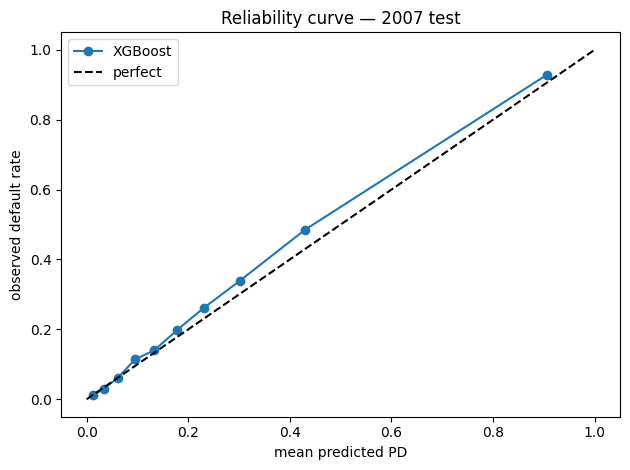

In [15]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

frac_pos, mean_pred = calibration_curve(yte, p_raw, n_bins=10, strategy="quantile")
plt.plot(mean_pred, frac_pos, "o-", label="XGBoost")
plt.plot([0, 1], [0, 1], "k--", label="perfect")
plt.xlabel("mean predicted PD"); plt.ylabel("observed default rate")
plt.title("Reliability curve — 2007 test"); plt.legend(); plt.tight_layout(); plt.show()

In [20]:
import joblib

joblib.dump(final_model, "final_behavioural_xgb.pkl")

# score EVERY vintage in the widened model_df — not just the test slice
X_all = apply_fe(model_df, A, include_behavioural=True).drop(columns=TARGET)

pd_output = pd.DataFrame({
    "loan_seq_no":      model_df.index,                    # loan ID lives in the index
    "origination_year": model_df["origination_year"].values,
    "PD":               final_model.predict_proba(X_all)[:, 1],
})
pd_output.to_parquet("behavioural_pd_output.parquet")

print("PDs saved:", pd_output.shape)
print("\nloans per vintage:")
print(pd_output.groupby("origination_year").size().to_string())
print("\nmean PD by vintage:")
print(pd_output.groupby("origination_year")["PD"].mean().round(4).to_string())

PDs saved: (471654, 3)

loans per vintage:
origination_year
2000    36472
2001    43109
2002    35346
2003    44658
2004    44431
2005    45553
2006    44772
2007    44157
2008    40395
2009    46687
2010    46074

mean PD by vintage:
origination_year
2000    0.1049
2001    0.0987
2002    0.0986
2003    0.0615
2004    0.0865
2005    0.1260
2006    0.1877
2007    0.2033
2008    0.1644
2009    0.0697
2010    0.0727


In [ ]:
def psi(expected, actual, bins=10):
    # bin edges from the reference distribution (quantile bins)
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf          # catch anything outside the range
    e_pct = np.histogram(expected, edges)[0] / len(expected)
    a_pct = np.histogram(actual,   edges)[0] / len(actual)
    e_pct = np.clip(e_pct, 1e-6, None)             # avoid divide-by-zero / log(0)
    a_pct = np.clip(a_pct, 1e-6, None)
    return float(np.sum((e_pct - a_pct) * np.log(e_pct / a_pct)))

# SCORE PSI: predicted PDs, calm vintage (2005) vs crisis vintage (2007)
ref  = model_df[model_df["origination_year"] == 2005]
new  = model_df[model_df["origination_year"] == 2007]
p_ref = final_model.predict_proba(apply_fe(ref, A).drop(columns=TARGET))[:, 1]
p_new = final_model.predict_proba(apply_fe(new, A).drop(columns=TARGET))[:, 1]
score_psi = psi(p_ref, p_new)
band = "stable" if score_psi < 0.1 else ("moderate shift" if score_psi < 0.25 else "MAJOR shift")
print(f"Score PSI (2005 -> 2007): {score_psi:.3f}  [{band}]\n")

# FEATURE PSI: which behavioural features drifted most into the crisis
def psi_pooled(expected, actual, bins=10):
    expected = np.asarray(expected, dtype=float)
    actual   = np.asarray(actual,   dtype=float)
    pooled   = np.concatenate([expected, actual])

    # quantile edges over the POOLED distribution -> every bin can hold both groups
    edges = np.unique(np.quantile(pooled, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:                      # near-constant feature -> no meaningful PSI
        return 0.0
    edges[0], edges[-1] = -np.inf, np.inf

    e_pct = np.histogram(expected, edges)[0] / len(expected)
    a_pct = np.histogram(actual,   edges)[0] / len(actual)
    e_pct = np.clip(e_pct, 1e-6, None)
    a_pct = np.clip(a_pct, 1e-6, None)
    return float(np.sum((e_pct - a_pct) * np.log(e_pct / a_pct)))

# re-run feature PSI with pooled binning
ref = model_df[model_df["origination_year"] == 2005]
new = model_df[model_df["origination_year"] == 2007]

rows = []
for f in BEH_FEATS:
    val = psi_pooled(ref[f].values, new[f].values)
    rows.append({"feature": f, "PSI": round(val, 3),
                 "band": "stable" if val < 0.1 else ("moderate" if val < 0.25 else "MAJOR")})
psi_tbl = pd.DataFrame(rows).sort_values("PSI", ascending=False)
print("Feature PSI (2005 -> 2007), pooled-range bins:")
print(psi_tbl.to_string(index=False))

Score PSI (2005 -> 2007): 0.276  [MAJOR shift]

Feature PSI (2005 -> 2007), pooled-range bins:
                feature    PSI   band
unemp_change_since_orig 17.581  MAJOR
  hpi_growth_since_orig 17.274  MAJOR
           rate_last_12  1.645  MAJOR
           unemp_at_obs  1.641  MAJOR
      current_ltv_proxy  0.770  MAJOR
     upb_paydown_pct_12  0.359  MAJOR
         upb_volatility  0.058 stable
       paydown_vs_sched  0.036 stable
         months_current  0.022 stable
          times_dq60_12  0.000 stable
          dq_at_month12  0.000 stable
        redelinquent_12  0.000 stable
           dq_onsets_12  0.000 stable
            dq_slope_12  0.000 stable
         mnths_since_dq  0.000 stable
   dq_trend_h2_minus_h1  0.000 stable
        dq_last_quarter  0.000 stable
        underwater_flag  0.000 stable


In [19]:
for yr in sorted(model_df["origination_year"].unique()):
    sub = model_df[model_df["origination_year"] == yr]
    if sub["default_fwd"].sum() < 10: continue
    Xs = apply_fe(sub, A).drop(columns=TARGET)
    p = final_model.predict_proba(Xs)[:, 1]
    print(yr, "AUC:", round(roc_auc_score(sub["default_fwd"], p), 3),
          "PSI vs 2005:", round(psi_pooled(p_ref, p), 3), "| n:", len(sub))

2000 AUC: 0.868 PSI vs 2005: 0.095 | n: 36472
2001 AUC: 0.871 PSI vs 2005: 0.026 | n: 43109
2002 AUC: 0.854 PSI vs 2005: 0.032 | n: 35346
2003 AUC: 0.838 PSI vs 2005: 0.37 | n: 44658
2004 AUC: 0.864 PSI vs 2005: 0.1 | n: 44431
2005 AUC: 0.879 PSI vs 2005: 0.0 | n: 45553
2006 AUC: 0.852 PSI vs 2005: 0.166 | n: 44772
2007 AUC: 0.852 PSI vs 2005: 0.279 | n: 44157
2008 AUC: 0.858 PSI vs 2005: 0.086 | n: 40395
2009 AUC: 0.855 PSI vs 2005: 0.209 | n: 46687
2010 AUC: 0.819 PSI vs 2005: 0.163 | n: 46074
